# Apply an evolved proofreader policy to the whole brain & compare before/after

Takes the **final accepted policy** from a `proofreader_evolve` run, runs it on **all 12 GT skeletons** of brain 789202, and shows what its `merge_labels` repairs did:

1. **Metric comparison** — baseline (no edits) vs edited, per skeleton: split-repair score, `# Splits`, `% Merged Edges`, Edge Accuracy, `# Merges`.
2. **Volume visualization** — pick one SplitSite the policy *repaired*, and render its local receptive field (raw image + fragment skeletons) coloured by **baseline labels vs edited (merged) labels**, side by side, so the repair is visible in 3D context (mirrors `visualization_showcase.ipynb`).

The policy is `propose_edits` from the run's `gen<NN>/heuristics.accepted.py`; it reasons over GT-free fragment geometry only, so it is deployable. Scoring uses the same incremental scorer the evolution loop uses (verified equal to `segmentation_skeleton_metrics.evaluate`).

## 0. Setup — env, paths, parameters

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Same env / path setup as notebooks/load_skeletons_from_cache.ipynb.
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../configs/zihan_gcs_token.json"
os.environ["AWS_EC2_METADATA_DISABLED"] = "true"

# Make proofreader_evolve and the metrics package importable.
PROJ = Path("..").resolve()                      # exa-spim-agent/
sys.path.insert(0, str(PROJ))
sys.path.insert(0, str(PROJ.parent / "segmentation-skeleton-metrics" / "src"))

from proofreader_evolve.harness import incremental_scoring as inc
from proofreader_evolve.harness import dataset as ds
from proofreader_evolve.harness import candidate as cand
from proofreader_evolve.harness import scoring
from proofreader_evolve.harness.edit_handler import normalize_edits
from agentic_neuron_proofreader.utils import img_util

# --- Parameters -----------------------------------------------------------
BRAIN_ID = "789202"
RUN_NAME = "789202_20260623_005939"          # the evolution run to take the policy from
GEN = "gen20"                                  # which generation's accepted policy ('gen20' = final/best)
                                               # (larger = more context around the gap; ~1 voxel per
                                               #  anisotropy unit. Bump higher for an even wider field.)

RUNS = PROJ / "proofreader_evolve" / "runs"
RUN_DIR = RUNS / RUN_NAME
POLICY = RUN_DIR / GEN / "heuristics.accepted.py"
PREPARED = RUN_DIR / f"prepared_{BRAIN_ID}.pkl"
print("policy  :", POLICY, "\n  exists:", POLICY.exists())
print("prepared:", PREPARED, "\n  exists:", PREPARED.exists())

policy  : /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_005939/gen20/heuristics.accepted.py 
  exists: True
prepared: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_005939/prepared_789202.pkl 
  exists: True


## 1. Load the prepared brain and the fragment graph

`prepared_<brain>.pkl` is the candidate-invariant scoring state (GT graphs + fragment graphs, built once by the run). The cached fragment graph is what the policy enumerates SplitSites over.

In [2]:
prepared = inc.PreparedBrain.load(str(PREPARED))
cache_path = ds.default_cache_path(BRAIN_ID)
fragments_graph, _gt, _payload = ds.load_cached_graphs(cache_path)
all_gt = sorted(prepared.gt_graphs.keys())
print(f"{len(all_gt)} GT skeletons:", all_gt)
print("fragment graph nodes:", fragments_graph.number_of_nodes())

12 GT skeletons: ['N005-789202-SP', 'N006-789202-JG', 'N007-789202-PP', 'N010-789202-JT', 'N011-789202-IG', 'N013-789202-KS', 'N016-789202-HP', 'N018-789202-JM', 'N020-789202-PP', 'N021-789202-HP', 'N022-789202-JG', 'N023-789202-SP']
fragment graph nodes: 4490438


## 2. Run the final policy on the WHOLE brain → edits

We reproduce `candidate.run_candidate`'s edit-production path: enumerate SplitSites from the fragment graph (using the policy's own `ENUM_PARAMS`), call `propose_edits`, and keep the `merge_labels` edits. No GT is given to the policy.

In [3]:
propose_edits, policy_module = cand._load_policy(str(POLICY))

raw_enum = getattr(policy_module, "ENUM_PARAMS", None)
raw_enum = {**raw_enum} if isinstance(raw_enum, dict) else {}
raw_enum.setdefault("max_gap_um", 15.0)
enum_params = ds.resolve_enum_params(raw_enum)

# splits-only style enumeration (the run was splits-only): SplitSites only.
split_sites, merge_sites = cand._enumerate_sites_cached(
    fragments_graph, enum_params, enumerate_merges=False)
sites = list(split_sites) + list(merge_sites)
ctx = {
    "max_gap_um": enum_params["max_gap_um"], "enum_params": dict(enum_params),
    "fragments_graph": fragments_graph, "n_split_sites": len(split_sites),
    "n_merge_sites": len(merge_sites),
    "node_radius": getattr(fragments_graph, "node_radius", None),
    "read_image_patch": None,
}
edits = normalize_edits(propose_edits(sites, ctx))
edits = [e for e in edits if e.get("kind") == "merge_labels"]  # splits-only
print(f"enumerated {len(split_sites)} SplitSites; policy emitted {len(edits)} merge_labels edits")

enumerated 5000 SplitSites; policy emitted 3533 merge_labels edits


## 3. Score baseline (no edits) vs edited — all 12 skeletons

`gt_swc_names=None` scores every GT skeleton. The incremental scorer applies the `merge_labels` edits as a label-equivalence collapse and recomputes the real metrics.

In [4]:
base = inc.score_incremental(prepared, label_pairs=None, gt_swc_names=None, verbose=False)
edited = inc.score_incremental(prepared, edits=edits, gt_swc_names=None, verbose=False)
print(f"baseline scored in {base.seconds:.1f}s; edited scored in {edited.seconds:.1f}s")

# Split-repair classification of the edits against the FULL-brain label->neuron map
# (here we use all 12 GT skeletons, so it is the deployable 'how many real splits did
# we repair' count, not a leak-free gate signal).
label_gt_map = inc.label_gt_counts(prepared, gt_names=None)
repair = inc.classify_merge_edits(edits, label_gt_map)
print(f"split-repair on all GT: correct={repair['correct']} false={repair['false']} "
      f"unscored={repair['unscored']} (score = {repair['correct']-repair['false']})")

baseline scored in 200.5s; edited scored in 219.2s
split-repair on all GT: correct=817 false=2 unscored=2714 (score = 815)


## 4. Per-skeleton metric comparison (baseline vs edited)

In [5]:
COLS = ["Edge Accuracy", "% Merged Edges", "# Merges", "% Split Edges", "# Splits", "% Omit Edges"]
b = base.per_swc[COLS]
e = edited.per_swc.reindex(b.index)[COLS]
delta = (e - b).add_prefix("d")
comp = pd.concat([b.add_prefix("base "), e.add_prefix("edit "), delta], axis=1)
comp.loc["WEIGHTED MEAN"] = {
    **{f"base {c}": scoring._weighted_avg(base.per_swc, c) for c in COLS},
    **{f"edit {c}": scoring._weighted_avg(edited.per_swc, c) for c in COLS},
    **{f"d{c}": scoring._weighted_avg(edited.per_swc, c) - scoring._weighted_avg(base.per_swc, c) for c in COLS},
}
pd.set_option("display.width", 200, "display.max_columns", 40)
comp.round(3)

,base Edge Accuracy,base % Merged Edges,base # Merges,base % Split Edges,base # Splits,base % Omit Edges,edit Edge Accuracy,edit % Merged Edges,edit # Merges,edit % Split Edges,edit # Splits,edit % Omit Edges,dEdge Accuracy,d% Merged Edges,d# Merges,d% Split Edges,d# Splits,d% Omit Edges
N005-789202-SP,86.980,8.648,9.000,0.422,1061.000,3.948,81.930,13.833,11.000,0.388,967.000,3.854,-5.050,5.185,2.000,-0.034,-94.000,-0.095
N006-789202-JG,83.880,14.680,11.000,0.285,1200.000,1.156,80.980,17.598,12.000,0.271,1121.000,1.152,-2.900,2.918,1.000,-0.015,-79.000,-0.004
N007-789202-PP,91.960,2.314,5.000,0.371,582.000,5.355,89.550,4.867,5.000,0.336,524.000,5.251,-2.410,2.553,0.000,-0.035,-58.000,-0.104
N010-789202-JT,90.040,3.984,3.000,0.937,1390.000,5.037,89.770,4.312,3.000,0.914,1341.000,5.007,-0.270,0.328,0.000,-0.023,-49.000,-0.030
N011-789202-IG,94.130,1.796,1.000,0.482,675.000,3.594,94.200,1.796,1.000,0.448,626.000,3.560,0.070,0.000,0.000,-0.034,-49.000,-0.034
N013-789202-KS,56.910,41.041,37.000,0.212,782.000,1.838,46.160,51.859,39.000,0.191,686.000,1.790,-10.750,10.818,2.000,-0.021,-96.000,-0.047
N016-789202-HP,84.250,14.954,11.000,0.177,641.000,0.621,66.100,33.116,13.000,0.169,590.000,0.619,-18.150,18.162,2.000,-0.009,-51.000,-0.002
N018-789202-JM,56.710,42.930,4.000,0.116,564.000,0.244,42.970,56.689,5.000,0.097,473.000,0.240,-13.740,13.759,1.000,-0.018,-91.000,-0.004
N020-789202-PP,91.030,7.863,1.000,0.291,357.000,0.817,90.440,8.469,1.000,0.274,330.000,0.817,-0.590,0.606,0.000,-0.017,-27.000,0.000
N021-789202-HP,94.560,3.209,5.000,0.231,616.000,1.999,91.340,6.472,5.000,0.218,570.000,1.969,-3.220,3.263,0.000,-0.013,-46.000,-0.029


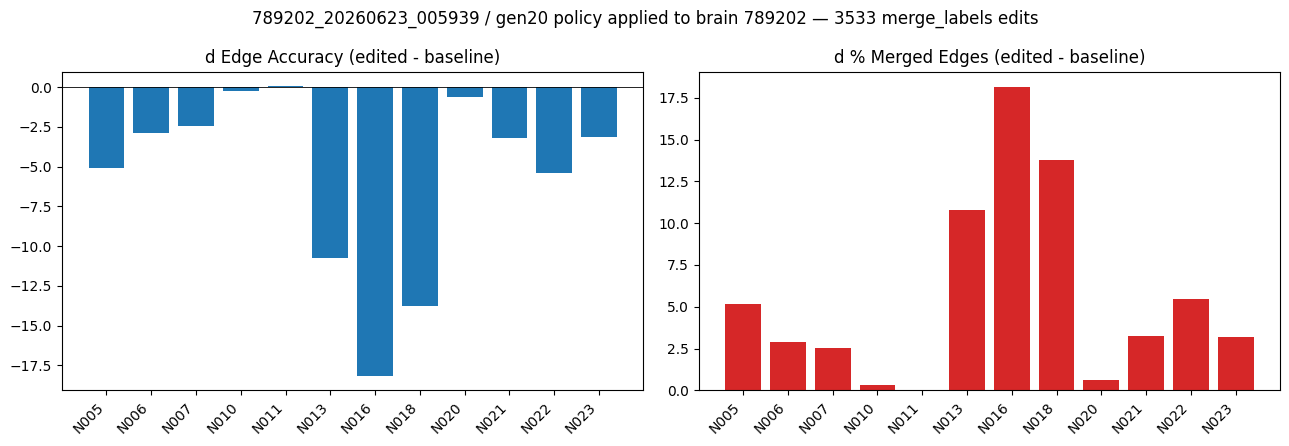

In [6]:
# Visual summary: per-skeleton dEdgeAcc and d%MergedEdges (the merge-error component).
names = [n for n in b.index]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(names))
axes[0].bar(x, delta.loc[names, "dEdge Accuracy"], color="#1f77b4")
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_title("d Edge Accuracy (edited - baseline)")
axes[0].set_xticks(x); axes[0].set_xticklabels([n.split('-')[0] for n in names], rotation=45, ha="right")
axes[1].bar(x, delta.loc[names, "d% Merged Edges"], color="#d62728")
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("d % Merged Edges (edited - baseline)")
axes[1].set_xticks(x); axes[1].set_xticklabels([n.split('-')[0] for n in names], rotation=45, ha="right")
fig.suptitle(f"{RUN_NAME} / {GEN} policy applied to brain {BRAIN_ID} — {len(edits)} merge_labels edits")
fig.tight_layout(); plt.show()

## 5. Pick a few repaired SplitSites to visualize

A **repaired** SplitSite = an enumerated SplitSite whose two fragment labels (a) the policy actually merged, and (b) belong to the SAME GT neuron (a real split it correctly closed). We pick `N_EXAMPLES` of them deterministically, spread evenly across the gap range (so the examples differ); each becomes one before/after panel below.

`RESTRICT_TO` (set in cell 0) limits which GT neurons the shown repairs may sit on — `None` (all 12), `"train"`, or `"heldout"` — using the run's `split.json`. It affects only **which examples are displayed**, never the scoring or the edits.

In [19]:
SEED = np.random.randint(0,10000)                                      # which repaired SplitSites to visualize (deterministic pick)
N_EXAMPLES = 10                                 # how many repaired SplitSites to visualize
RESTRICT_TO = None                             # which GT neurons the visualized repairs may sit on:
                                               #   None      -> all 12 GT skeletons (no restriction)
                                               #   "train"   -> only this run's TRAIN skeletons
                                               #   "heldout" -> only this run's HELD-OUT skeletons
                                               # (reads the run's split.json; affects ONLY which
                                               #  examples are shown, NOT scoring or the edits.)

In [20]:
def _pair_key(a, b):
    a, b = str(a), str(b); return (a, b) if a <= b else (b, a)

accepted = {_pair_key(e["label_a"], e["label_b"]) for e in edits}

def _dominant(lbl):
    c = label_gt_map.get(str(lbl)); return max(c, key=c.get) if c else None

# RESTRICT_TO -> the set of GT skeleton names a repair is allowed to sit on. Reads the
# run's split.json (the SAME train/held-out partition the evolution used). None = all.
allowed_neurons = None
if RESTRICT_TO is not None:
    split = json.loads((RUN_DIR / "split.json").read_text())
    per_brain = split["per_brain"][BRAIN_ID]
    key = {"train": "train", "heldout": "heldout"}[RESTRICT_TO]
    allowed_neurons = set(per_brain[key])
    print(f"RESTRICT_TO={RESTRICT_TO!r}: {len(allowed_neurons)} GT skeletons -> {sorted(allowed_neurons)}")
else:
    print("RESTRICT_TO=None: any of the 12 GT skeletons")

repaired = []  # SplitSites the policy merged AND that are real splits (same GT neuron)
for s in split_sites:
    la, lb = str(s.label_a), str(s.label_b)
    if _pair_key(la, lb) not in accepted:
        continue
    da, db = _dominant(la), _dominant(lb)
    if da is None or da != db:
        continue
    if allowed_neurons is not None and da not in allowed_neurons:
        continue                      # repair sits on a neuron outside the requested split
    repaired.append(s)
print(f"{len(repaired)} repaired real-split SplitSites available"
      + (f" on {RESTRICT_TO} neurons" if RESTRICT_TO else ""))
assert repaired, "no repaired SplitSites match the filter — try RESTRICT_TO=None or another GEN"

# Deterministic, spread-out pick: sort by gap and take N_EXAMPLES evenly-spaced
# samples from the middle band (skip the extreme-near/extreme-far tails). Shift by
# SEED to get a different (still reproducible) set.
repaired.sort(key=lambda s: s.gap_um)
band = repaired[len(repaired)//10 : 9*len(repaired)//10] or repaired
idxs = [int((k + 0.5) * len(band) / N_EXAMPLES) + SEED for k in range(N_EXAMPLES)]
sites_to_show = [band[i % len(band)] for i in idxs]

for k, s in enumerate(sites_to_show):
    c = tuple((np.asarray(s.xyz_a, float) + np.asarray(s.xyz_b, float)) / 2.0)
    print(f"  example {k}: {s.label_a} <-> {s.label_b}, gap {s.gap_um:.2f} um, "
          f"GT neuron {_dominant(s.label_a)}, center(um) {tuple(round(v,1) for v in c)}")

RESTRICT_TO=None: any of the 12 GT skeletons
817 repaired real-split SplitSites available
  example 0: 156096417 <-> 243436246, gap 2.24 um, GT neuron N016-789202-HP, center(um) (np.float64(13237.3), np.float64(16811.7), np.float64(4177.6))
  example 1: 508848040 <-> 435052706, gap 2.45 um, GT neuron N005-789202-SP, center(um) (np.float64(32977.5), np.float64(18002.0), np.float64(8701.5))
  example 2: 920140111 <-> 890636428, gap 2.50 um, GT neuron N022-789202-JG, center(um) (np.float64(25902.7), np.float64(16366.5), np.float64(15818.1))
  example 3: 423008175 <-> 422935677, gap 2.71 um, GT neuron N010-789202-JT, center(um) (np.float64(24205.8), np.float64(22913.5), np.float64(7334.8))
  example 4: 672570693 <-> 643212857, gap 2.83 um, GT neuron N013-789202-KS, center(um) (np.float64(12405.0), np.float64(21755.0), np.float64(11494.0))
  example 5: 274017404 <-> 184925794, gap 3.00 um, GT neuron N020-789202-PP, center(um) (np.float64(6438.0), np.float64(19250.5), np.float64(4826.0))
  e

## 6. Visualize the repaired regions — MIP + GT + fragments, BEFORE vs AFTER

For each chosen SplitSite (3 in total), the same panels as `visualization_showcase.ipynb`:

1. **Raw image MIP** (XY / XZ / YZ) — the fluorescence the policy implicitly trusted at the gap.
2. **GT skeleton** (lime) — shown **once** as the truth reference.
3. **Fragments BEFORE** — coloured by raw connected component: the two fragments at the site are **different colours** (the split the segmentation made).
4. **Fragments AFTER** — coloured by the policy's edited equivalence class: the merged pair is now **one colour** (the repair).

Skeletons are proper edge MIPs (lines, not dots) via `plot_skeleton_mips`.

In [21]:
PATCH = 160                                   # receptive-field cube side (voxels) for the volume viz

In [24]:
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset
from proofreader_evolve.harness.edit_handler import EditHandler

# Same *_add.pkl cache visualization_showcase uses: agentic SkeletonGraph
# (nodes_in_patch / edges_in_patch / node_component_id / node_segment_id) + GCS reader.
add_cache = f"../cache/dataset_cache_{BRAIN_ID}_mcl100_add.pkl"
bd = BrainDataset.load_from_cache(add_cache)
gt_viz, fr_viz = bd.gt_graph, bd.fragments_graph
aniso = gt_viz.anisotropy
handler = EditHandler(edits, all_labels=prepared.all_fragment_labels)
PATCH_SHAPE = (PATCH, PATCH, PATCH)

SHOW_SLICES = True                              # also show multi-depth raw-image slices
SLICE_FRACTIONS = (0.2, 0.4, 0.5, 0.6, 0.8)     # depth fractions for plot_slices rows


def plot_slices(patch, title="", fractions=SLICE_FRACTIONS):
    """Several single-plane SLICES at increasing depth, in ONE figure (from
    visualization_showcase.ipynb). Unlike a MIP (which maxes over the whole depth),
    each panel is one true imaging layer ``patch[int(f*depth)]``. Rows = depth
    fraction along the projection axis; columns = XY / XZ / YZ."""
    nz, ny, nx = patch.shape
    names = ["XY (vary z)", "XZ (vary y)", "YZ (vary x)"]
    sizes = [nz, ny, nx]
    vmax = np.percentile(patch, 99.9)
    nrows = len(fractions)
    fig, axs = plt.subplots(nrows, 3, figsize=(10, 3.2 * nrows))
    axs = np.atleast_2d(axs)
    for r, frac in enumerate(fractions):
        idx = [min(int(frac * s), s - 1) for s in sizes]
        planes = [patch[idx[0]], patch[:, idx[1]], patch[:, :, idx[2]]]
        for c, (ax, plane, nm) in enumerate(zip(axs[r], planes, names)):
            ax.imshow(plane, cmap="gray", vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(nm, fontsize=14)
            if c == 0:
                ax.set_ylabel(f"{int(frac * 100)}% depth\n(plane {idx[0]})", fontsize=12)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_example(site):
    """Render ONE repaired SplitSite the visualization_showcase way:
       (1) raw-image MIP (XY/XZ/YZ),
       (1b) raw-image multi-depth SLICES (when SHOW_SLICES),
       (2) GT skeleton MIPs (lime) — shown ONCE, the truth reference,
       (3) fragment skeleton MIPs BEFORE the edit (coloured by raw component),
       (4) fragment skeleton MIPs AFTER  the edit (coloured by merged class).
    The two fragments the policy merged are DIFFERENT colours before and ONE colour
    after; GT is the same in both, so we draw it only once.
    """
    center_um = tuple((np.asarray(site.xyz_a, float) + np.asarray(site.xyz_b, float)) / 2.0)
    center_voxel = img_util.to_voxels(center_um, aniso)          # (z, y, x)
    offset = tuple(c - s // 2 for c, s in zip(center_voxel, PATCH_SHAPE))
    img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))

    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_nodes, fr_nid, fr_ncomp = fr_viz.nodes_in_patch(
        offset, PATCH_SHAPE, return_ids=True, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)

    # Remap fragment component-id -> the policy's edited equivalence class, so the
    # merged pair shares a colour AFTER. (BEFORE keeps the raw component id.)
    comp_rep = {}
    for nid, comp in zip(fr_nid, fr_ncomp):
        comp_rep.setdefault(int(comp), int(nid))
    comp_edited = {c: handler.get(str(fr_viz.node_segment_id(rep))) for c, rep in comp_rep.items()}
    cls_int = {cls: i for i, cls in enumerate(sorted(set(comp_edited.values())))}
    def to_after(arr):
        return np.array([cls_int[comp_edited[int(c)]] for c in arr], dtype=int)
    fr_ncomp_after, fr_ecomp_after = to_after(fr_ncomp), to_after(fr_ecomp)

    tag = (f"SplitSite {site.label_a}+{site.label_b}  gap {site.gap_um:.2f} µm  "
           f"GT {_dominant(site.label_a)}  @ {tuple(round(v,1) for v in center_um)} µm")
    print(f"\n=== {tag} ===")
    print(f"GT nodes/edges in patch: {len(gt_nodes)}/{len(gt_edges)}   "
          f"fragment nodes/edges: {len(fr_nodes)}/{len(fr_edges)}")

    print("Raw image (MIP):")
    img_util.plot_mips(img_patch)
    if SHOW_SLICES:
        print(f"Raw image (slices at {[int(f*100) for f in SLICE_FRACTIONS]}% depth):")
        plot_slices(img_patch)

    print("GT skeleton (lime) — truth reference, shown once:")
    img_util.plot_skeleton_mips({
        "GT": {"nodes": gt_nodes, "node_components": gt_ncomp,
               "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments BEFORE — by raw connected component (the split = two colours):")
    img_util.plot_skeleton_mips({
        "Fragments (before)": {"nodes": fr_nodes, "node_components": fr_ncomp,
                               "edges": fr_edges, "components": fr_ecomp, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

    print("Fragments AFTER — by policy's merged class (the repair = one colour):")
    img_util.plot_skeleton_mips({
        "Fragments (after)": {"nodes": fr_nodes, "node_components": fr_ncomp_after,
                              "edges": fr_edges, "components": fr_ecomp_after, "color": "cyan"},
    }, PATCH_SHAPE, separate_rows=True)

print("setup ready: show_example()")

setup ready: show_example()


In [27]:
from matplotlib.backends.backend_pdf import PdfPages

# Render each chosen example and save ITS figures (raw MIP, depth slices, GT,
# fragments before/after) into its OWN multi-page PDF, under a dedicated subfolder
# of this run: runs/<run>/policy_viz/. One site -> one PDF (5 pages).
#
# The showcase plotters call plt.show() internally; under the Jupyter INLINE backend
# that *closes* each figure, so we'd collect none. We temporarily replace plt.show
# with a no-op so figures persist until written, then restore it. (Figures go to the
# PDFs, not inline — open the PDFs to view.)
VIZ_DIR = RUN_DIR / "policy_viz"
VIZ_DIR.mkdir(parents=True, exist_ok=True)

_real_show = plt.show
plt.show = lambda *a, **k: None
try:
    for k, s in enumerate(sites_to_show):
        plt.close("all")                          # isolate THIS site's figures
        show_example(s)
        figs = [plt.figure(num) for num in plt.get_fignums()]
        # One PDF per site: index + label pair + GT neuron (no seed in the name).
        name = f"ex{k:02d}_{s.label_a}-{s.label_b}_{_dominant(s.label_a)}.pdf"
        pdf_path = VIZ_DIR / name
        with PdfPages(pdf_path) as pdf:
            for f in figs:
                pdf.savefig(f, bbox_inches="tight")
        print(f"  saved {len(figs)} figures -> {pdf_path}")
finally:
    plt.show = _real_show
    plt.close("all")
print(f"\ndone: {len(sites_to_show)} per-site PDFs in {VIZ_DIR}")


=== SplitSite 156096417+243436246  gap 2.24 µm  GT N016-789202-HP  @ (np.float64(13237.3), np.float64(16811.7), np.float64(4177.6)) µm ===
GT nodes/edges in patch: 71/70   fragment nodes/edges: 63/60
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth reference, shown once:
Fragments BEFORE — by raw connected component (the split = two colours):
Fragments AFTER — by policy's merged class (the repair = one colour):
  saved 5 figures -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/runs/789202_20260623_005939/policy_viz/ex00_156096417-243436246_N016-789202-HP.pdf

=== SplitSite 508848040+435052706  gap 2.45 µm  GT N005-789202-SP  @ (np.float64(32977.5), np.float64(18002.0), np.float64(8701.5)) µm ===
GT nodes/edges in patch: 106/102   fragment nodes/edges: 91/86
Raw image (MIP):
Raw image (slices at [20, 40, 50, 60, 80]% depth):
GT skeleton (lime) — truth reference, shown once:
Fragm

## 7. (optional) Export the edits for this brain

The lightweight, auditable artifact: every `merge_labels` pair the policy proposed. (We do not materialize a repaired voxel volume — edits are a label-equivalence overlay, see `proofreader_evolve/todo.md`.)

In [10]:
# out = Path(f"./{RUN_NAME}_{GEN}_{BRAIN_ID}_edits.json")
# out.write_text(json.dumps({
#     "run": RUN_NAME, "generation": GEN, "brain": BRAIN_ID,
#     "n_edits": len(edits),
#     "split_repair": {k: repair[k] for k in ("correct", "false", "unscored")},
#     "edits": edits,
# }, indent=2))
# print("wrote", out, f"({len(edits)} edits)")